In [1]:
import pandas as pd       # Importing pandas for data manipulation
import numpy as np        # Importing numpy for numerical operations
import matplotlib.pyplot as plt  # Importing matplotlib for static data visualization
import seaborn as sns     # Importing seaborn for advanced statistical plotting
import plotly.express as px  # Importing plotly for interactive visualizations


In [2]:
df = pd.read_csv("car data.csv")  # Loading the dataset from a CSV file
df.head()                         # Displaying the first 5 rows of the dataset


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.shape  # Returns the number of rows and columns in the dataset


(301, 9)

In [4]:
df.info()  # Displays summary info about the dataset (data types, non-null counts)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


# Data cleaning


In [5]:
print(df.isnull().sum())  # Prints the number of missing values in each column


Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [6]:
print(df.columns)  # Prints the names of all columns in the dataset


Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')


Data is cleaned


# EDA


In [7]:
df.describe()  # Displays statistical summary for numerical columns


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
fig = px.scatter(df, x="Present_Price", y="Selling_Price", trendline="ols")  # Creates scatter plot with regression line
fig.update_layout(title="Relation between Selling Price and Present Price")  # Sets the plot title
fig.show()  # Displays the interactive plot
plt.show()  # (Not needed here, used with matplotlib)


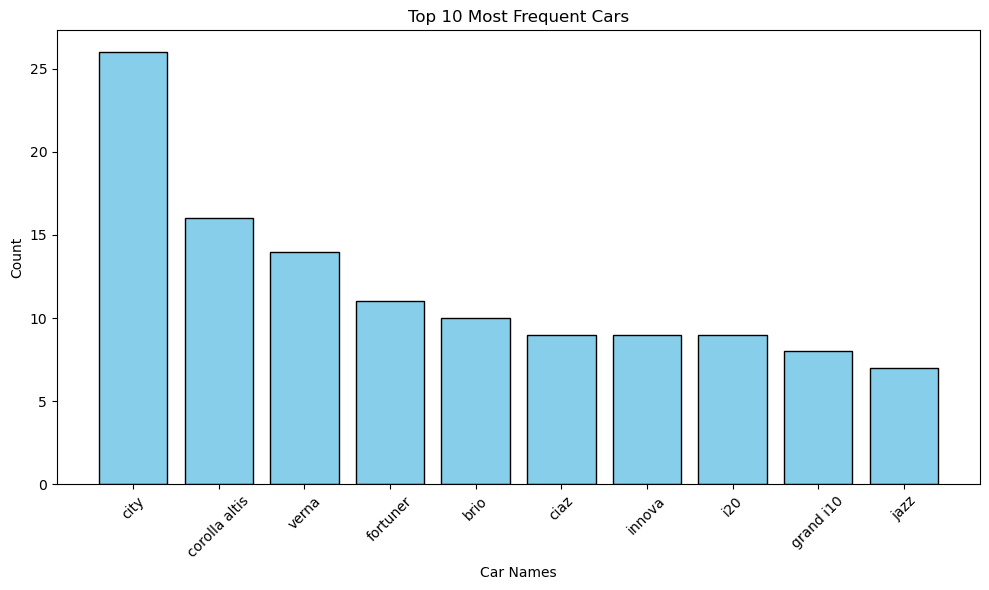

In [9]:
top_cars = df["Car_Name"].value_counts().head(10)  # Gets the top 10 most frequent car names

plt.figure(figsize=(10, 6))  # Sets the figure size
plt.bar(top_cars.index, top_cars.values, color='skyblue', edgecolor='black')  # Creates a bar chart
plt.title("Top 10 Most Frequent Cars")  # Sets the chart title
plt.xlabel("Car Names")  # X-axis label
plt.ylabel("Count")  # Y-axis label
plt.xticks(rotation=45)  # Rotates x-axis labels
plt.tight_layout()  # Adjusts layout to prevent overlap
plt.show()  # Displays the plot


# Data Preparation & Feature Engineering


In [10]:
df['Brand'] = df['Car_Name'].apply(lambda x: x.split()[0])  # Extracts the brand name from the car name


In [11]:
print(df.columns)  # Prints the updated list of column names including the new 'Brand' column


Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Brand'],
      dtype='object')


In [12]:
df = pd.get_dummies(df, columns=['Brand'], drop_first=True)  # Applies one-hot encoding to 'Brand' and drops the first category


In [13]:
features = ['Year', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type',
            'Transmission', 'Owner']  # Selected feature columns

X = df[features]  # Features (independent variables)
y = df['Selling_Price']  # Target (dependent variable)


In [14]:
categorical_cols = ['Fuel_Type', 'Selling_type', 'Transmission']  # List of categorical columns to encode

X = pd.get_dummies(df[features], columns=categorical_cols, drop_first=True)  # Applying one-hot encoding and dropping first category to avoid multicollinearity


# Model building


In [15]:
from sklearn.model_selection import train_test_split  # Importing function to split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)  # Splitting data into training and testing sets (80% train, 20% test)


In [16]:
from sklearn.linear_model import LinearRegression  # Importing Linear Regression model
model = LinearRegression()  # Creating the model object
model.fit(X_train, y_train)  # Training the model on the training data

y_pred = model.predict(X_test)  # Predicting target values for the test set


In [17]:
from sklearn.metrics import r2_score, mean_squared_error  # Importing evaluation metrics

r2 = r2_score(y_test, y_pred)  # Calculating R² score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # Calculating Root Mean Squared Error

print(f'R² Score: {r2:.3f}')  # Printing R² score
print(f'RMSE: {rmse:.3f}')  # Printing RMSE


R² Score: 0.849
RMSE: 1.866


In [18]:
from sklearn.ensemble import RandomForestRegressor  # Importing Random Forest Regressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)  # Creating the model with 100 trees
rf_model.fit(X_train, y_train)  # Training the model

rf_pred = rf_model.predict(X_test)  # Predicting using the trained model

from sklearn.metrics import r2_score, mean_squared_error  # Importing evaluation metrics
print("Random Forest R²:", r2_score(y_test, rf_pred))  # Printing R² score
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))  # Printing RMSE



Random Forest R²: 0.9643601062650229
Random Forest RMSE: 0.906082658716206


In [19]:
import joblib  # Importing joblib for model serialization

joblib.dump(rf_model, 'selling_price_model.pkl')  # Saving the trained model to a file


['selling_price_model.pkl']

In [20]:
print(model.feature_names_in_)


['Year' 'Present_Price' 'Driven_kms' 'Owner' 'Fuel_Type_Diesel'
 'Fuel_Type_Petrol' 'Selling_type_Individual' 'Transmission_Manual']
